# Problem Statement : Predict Car Price

## Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Load the Dataset

In [3]:
data = pd.read_csv('Car_Details.csv')

In [4]:
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


## Dataset Overview

In [5]:
data.shape

(4340, 8)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [7]:
# numerical columns description
data.describe(include='number')

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


- min year: 1992, max year: 2020, average: 2013
- avg km driven: 66215

In [8]:
# categorical columns description
data.describe(include='object')

,name,fuel,seller_type,transmission,owner
count,4340,4340,4340,4340,4340
unique,1491,5,3,2,5
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner
freq,69,2153,3244,3892,2832


In [11]:
print(data['transmission'].unique())
print(data['seller_type'].unique())
print(data['owner'].unique())
print(data['fuel'].unique())

['Manual' 'Automatic']
['Individual' 'Dealer' 'Trustmark Dealer']
['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']
['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']


## Data Preparation

### Feature Subset Selection

In [12]:
data['name'].nunique()

1491

Since Car Name contains 1491 unique categories, and this number of categories is very high compared to the number of dataset samples, it is better to drop it:

In [13]:
data.drop('name', axis=1, inplace=True)

### Feature Transformation

- `Year` shows the car model year. We can replace this column with the cars `age` attribute.
- To calculate the age, we consider the origin time to be 1 year older than the maximum model year:

In [14]:
data.insert(0, "Age", data["year"].max()+1-data["year"]) # age column with all zeros get replaced with max age + 1 - year
data.drop('year', axis=1, inplace=True)
data.head()

,Age,selling_price,km_driven,fuel,seller_type,transmission,owner
0,14,60000,70000,Petrol,Individual,Manual,First Owner
1,14,135000,50000,Petrol,Individual,Manual,First Owner
2,9,600000,100000,Diesel,Individual,Manual,First Owner
3,4,250000,46000,Petrol,Individual,Manual,First Owner
4,7,450000,141000,Diesel,Individual,Manual,Second Owner


### Discover Missing Values

In [15]:
data.isnull().sum()

Age              0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

__There is no missing value in the dataset.__

### Discover Duplicates

In [16]:
data[data.duplicated(keep=False)]

,Age,selling_price,km_driven,fuel,seller_type,transmission,owner
0,14,60000,70000,Petrol,Individual,Manual,First Owner
1,14,135000,50000,Petrol,Individual,Manual,First Owner
2,9,600000,100000,Diesel,Individual,Manual,First Owner
3,4,250000,46000,Petrol,Individual,Manual,First Owner
4,7,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...
4311,4,1900000,20118,Petrol,Dealer,Automatic,First Owner
4319,9,400000,70000,Diesel,Individual,Manual,First Owner
4322,8,500000,120000,Diesel,Individual,Manual,First Owner
4335,7,409999,80000,Diesel,Individual,Manual,Second Owner


**Since it is possible to have cars with the same features, we do not drop duplicates.**

## EDA

### Categorical Variables Univariate Analysis

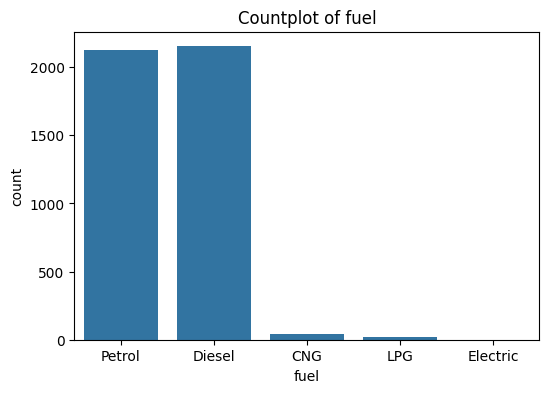

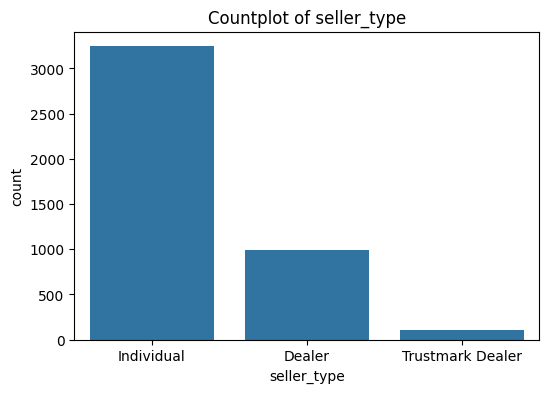

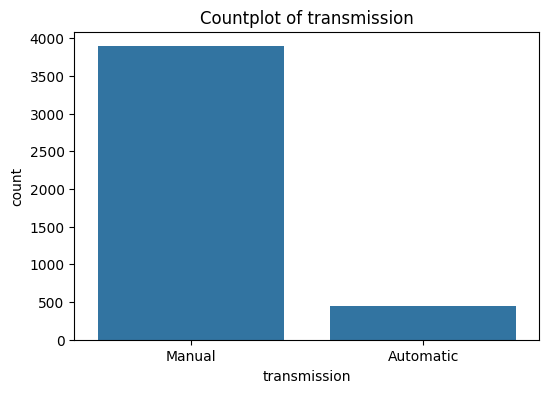

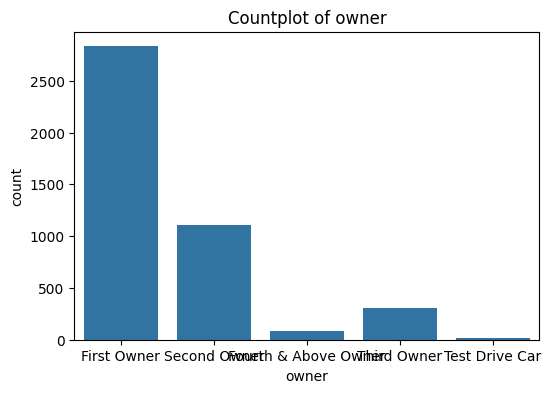

In [17]:
categorical_features = ['fuel','seller_type', 'transmission','owner']

for feature in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=data, x=feature)
    plt.title(f'Countplot of {feature}')
    plt.show()

### Conclusion:
* There are 5 Fuel_Type categories. Diesel has the highest frequency and CNG, LPG and Electric has the least frequency.
* There are 3 Seller_Type categories. Individual has the highest frequency and Trustmark Dealer has the least frequency.
* There are 2 Transmission categories. Manual has the highest frequency and Automatic has the least frequency.
* There are 5 Owner categories. First Owner has the higest frequency.

### Bivariate analysis

In [18]:
data.columns

Index(['Age', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')

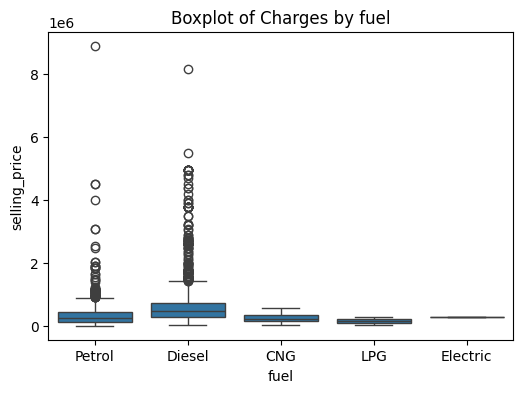

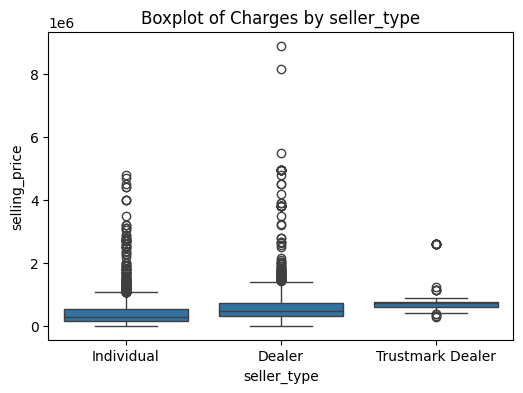

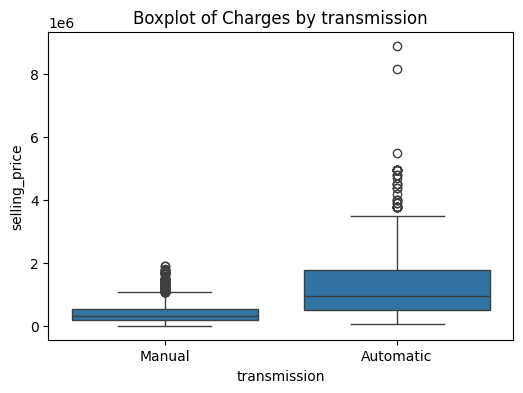

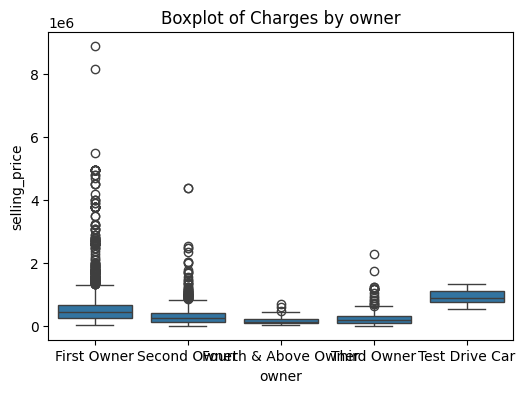

In [19]:
# Boxplots for selling price across categories
categorical_features = ['fuel','seller_type','transmission', 'owner']

for feature in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=data, x=feature, y='selling_price')
    plt.title(f'Boxplot of Charges by {feature}')
    plt.show()

### Outlier Detection


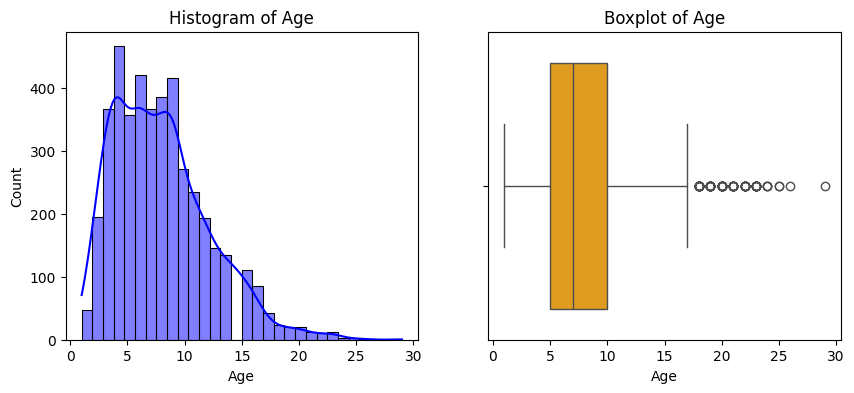

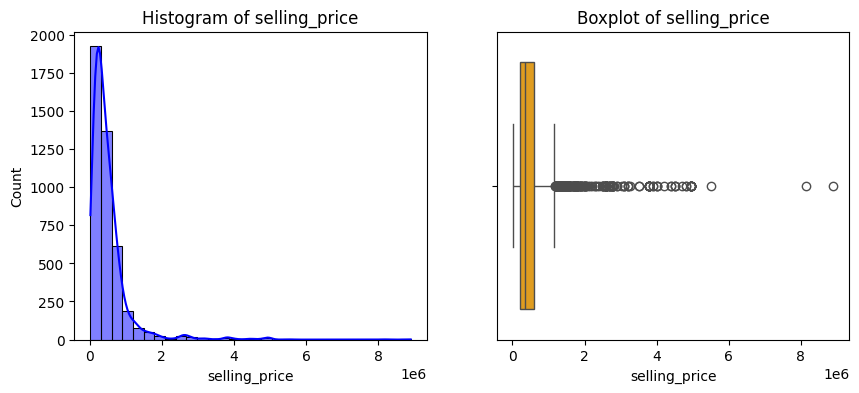

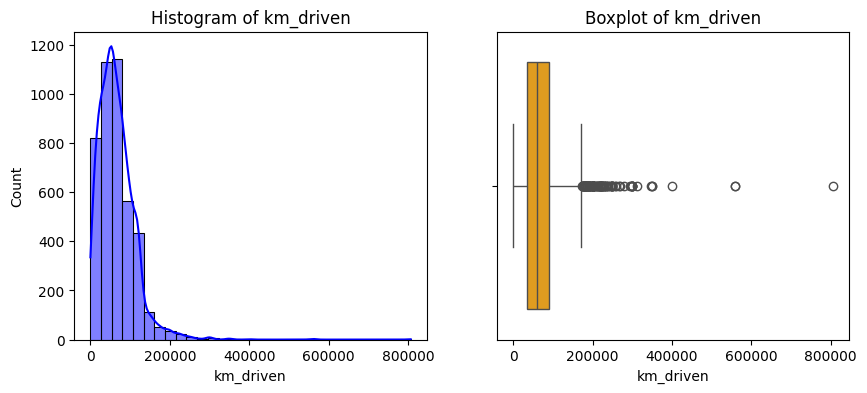

In [20]:
# Plot histograms and boxplots
numeric_features = ['Age', 'selling_price','km_driven']

for feature in numeric_features:
    plt.figure(figsize=(10, 4))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(data[feature], kde=True, bins=30, color='blue')
    plt.title(f'Histogram of {feature}')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[feature], color='orange')
    plt.title(f'Boxplot of {feature}')

    plt.show()

It is not acceptable to drop an observation just because it is an outlier. They can be legitimate observations and it’s important to investigate the nature of the outlier before deciding whether to drop it or not. We are allowed to delete outliers in two cases:__

* __Outlier is due to incorrectly entered or measured data__
* __Outlier creates a significant association__

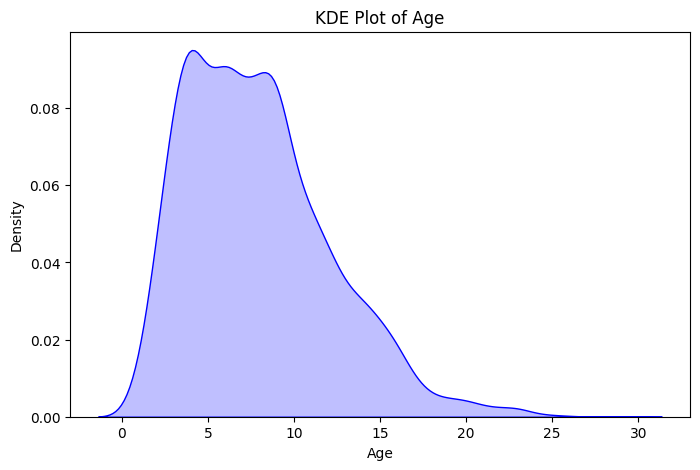

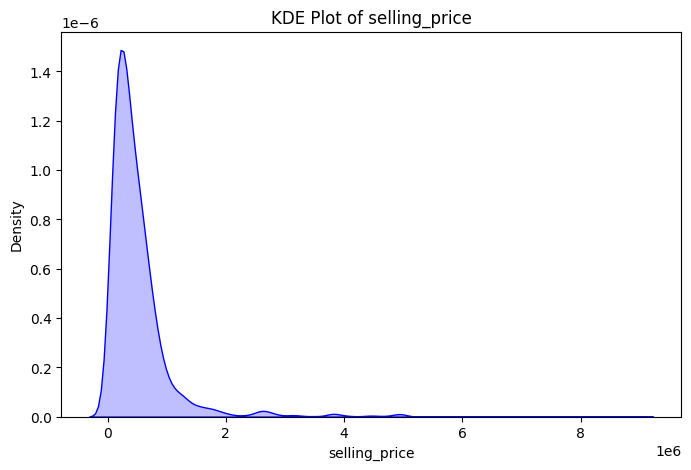

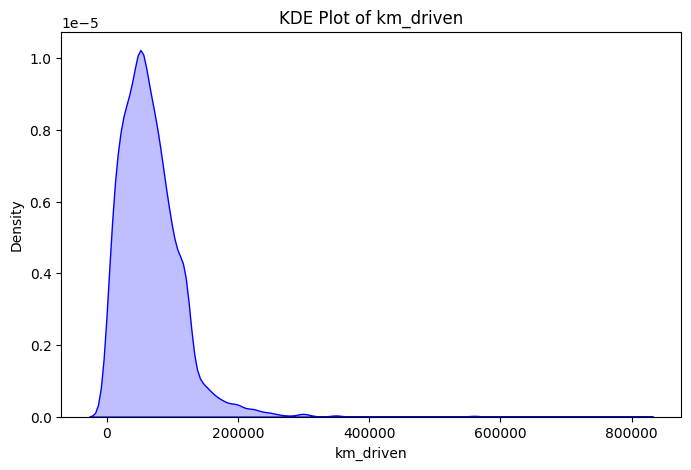

In [86]:
numeric_features = ['Age', 'selling_price', 'km_driven']

for feature in numeric_features:
    plt.figure(figsize=(8, 5))

    # KDE plot
    sns.kdeplot(data[feature], shade=True, color='blue')
    plt.title(f'KDE Plot of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.show()

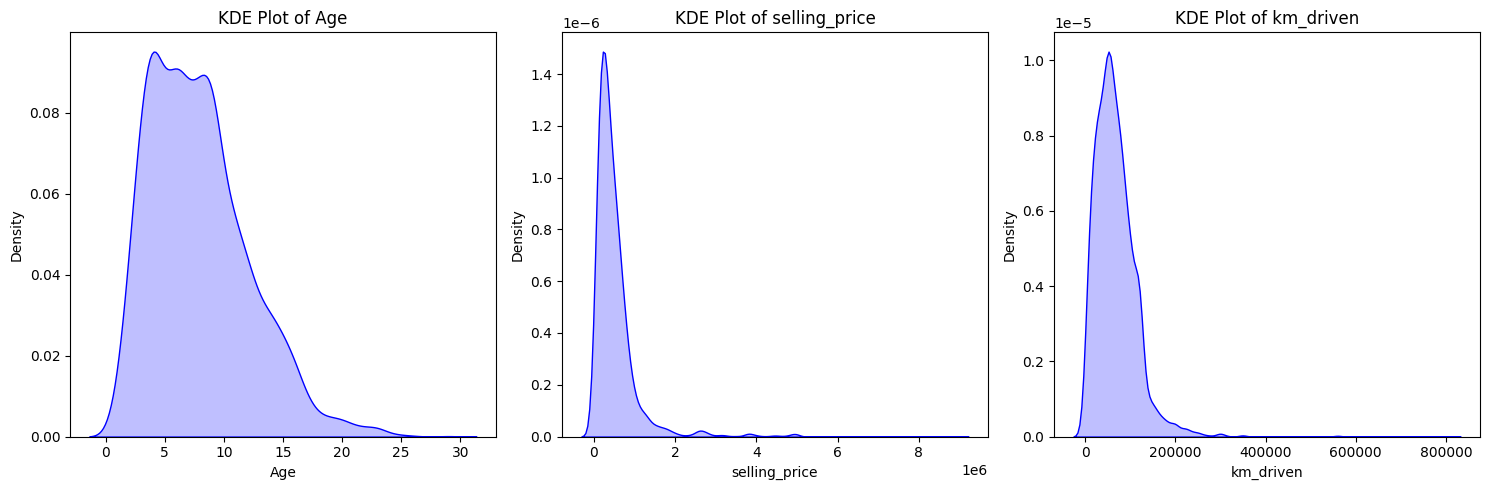

In [21]:
num_features = len(numeric_features)
plt.figure(figsize=(5 * num_features, 5))  # Adjust the figure size based on the number of features

for i, feature in enumerate(numeric_features):
    plt.subplot(1, num_features, i + 1)  # Create subplots in a single row
    sns.kdeplot(data[feature], shade=True, color='blue')
    plt.title(f'KDE Plot of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')

plt.tight_layout()  # Adjust spacing to avoid overlap
plt.show()

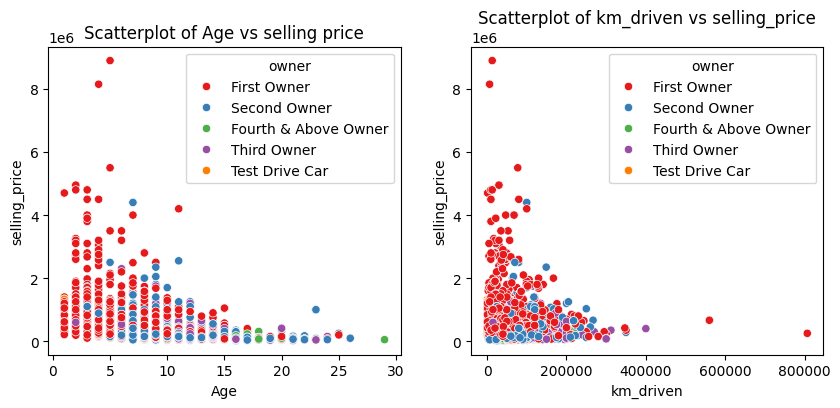

In [22]:
# Scatterplots for selling price vs other numeric features
plt.figure(figsize=(10, 4))

plt.subplot(1,2,1)
sns.scatterplot(data=data, x='Age', y='selling_price', hue='owner', palette='Set1')
plt.title(f'Scatterplot of Age vs selling price')

plt.subplot(1,2,2)
sns.scatterplot(data=data, x='km_driven', y='selling_price', hue='owner', palette='Set1')
plt.title(f'Scatterplot of km_driven vs selling_price')

plt.show()

- age below 5 and first owner tend to have high selling price
- km driven is below 2lakh and first owner cars are selling for higher price

## Categorical Variables Encoding
We implement dummy encoding on categorical columns, since they are all nominal variables:

In [23]:
categorical_features = ['fuel','seller_type','transmission', 'owner']

df_encoded = pd.get_dummies(data, columns=categorical_features, drop_first=True).astype(int)
df_encoded.head(5)

,Age,selling_price,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,14,60000,70000,0,0,0,1,1,0,1,0,0,0,0
1,14,135000,50000,0,0,0,1,1,0,1,0,0,0,0
2,9,600000,100000,1,0,0,0,1,0,1,0,0,0,0
3,4,250000,46000,0,0,0,1,1,0,1,0,0,0,0
4,7,450000,141000,1,0,0,0,1,0,1,0,1,0,0


## Correlation Analysis

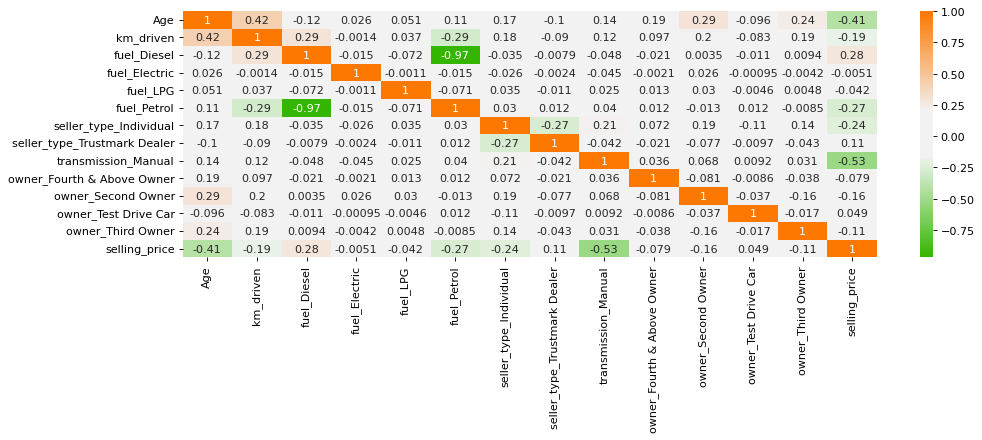

In [28]:
target = 'selling_price'
cmap = sns.diverging_palette(125, 28, s=100, l=65, sep=50, as_cmap=True)
fig, ax = plt.subplots(figsize=(14, 4), dpi=80)
ax = sns.heatmap(pd.concat([df_encoded.drop(target,axis=1), df_encoded[target]],axis=1).corr(), annot=True, cmap=cmap)
plt.show()

* The target variable "Selling Price" is highly correlated with Age & transmission & seller_type.
* Some independent variables like Fuel_Petrol and Fuel_Disel are highly correlated, which is called Multicollinearity.

## Split Data

In [32]:
X = df_encoded.drop('selling_price', axis=1)
y = df_encoded['selling_price']

In [33]:
X.head()

,Age,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,14,70000,0,0,0,1,1,0,1,0,0,0,0
1,14,50000,0,0,0,1,1,0,1,0,0,0,0
2,9,100000,1,0,0,0,1,0,1,0,0,0,0
3,4,46000,0,0,0,1,1,0,1,0,0,0,0
4,7,141000,1,0,0,0,1,0,1,0,1,0,0


## Split Dataset to Training & Test Sets

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
print('X_train shape: ', X_train.shape)
print('X_test shape: ', X_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ',y_test.shape)

X_train shape:  (3472, 13)
X_test shape:  (868, 13)
y_train shape:  (3472,)
y_test shape:  (868,)


## Step 8.3: Scale Data using Standard Scaler

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
X_train_scaled

array([[-0.92342078, -0.98114024,  1.01275414, ..., -0.58178467,
        -0.06587126, -0.27553931],
       [-1.16122801, -0.34146273,  1.01275414, ..., -0.58178467,
        -0.06587126, -0.27553931],
       [ 0.0278081 , -0.87452732, -0.98740648, ...,  1.71884901,
        -0.06587126, -0.27553931],
       ...,
       [-0.68561356, -0.32014015,  1.01275414, ..., -0.58178467,
        -0.06587126, -0.27553931],
       [ 0.0278081 ,  0.29821478,  1.01275414, ..., -0.58178467,
        -0.06587126, -0.27553931],
       [ 0.0278081 ,  0.29821478, -0.98740648, ..., -0.58178467,
        -0.06587126, -0.27553931]])

__It is very important that StandardScaler transformation should only be learnt from the training set, otherwise it will lead to data leakage.__

## Step 8.4: Train the Model

In [39]:
from sklearn.linear_model import LinearRegression

linear_reg = LinearRegression()
linear_reg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
pd.DataFrame(data = np.append(linear_reg.intercept_ , linear_reg.coef_),
             index = ['Intercept']+[col+" Coef." for col in X.columns], columns=['Value']).sort_values('Value', ascending=False)

,Value
Intercept,507767.468318
fuel_Diesel Coef.,139914.155959
seller_type_Trustmark Dealer Coef.,25320.616048
owner_Test Drive Car Coef.,8570.854655
fuel_LPG Coef.,3841.002203
owner_Fourth & Above Owner Coef.,87.386207
owner_Third Owner Coef.,-6931.174889
fuel_Petrol Coef.,-10346.919035
fuel_Electric Coef.,-10861.968495
owner_Second Owner Coef.,-15667.732776


## Step 8.5: Model Evaluation

In [43]:
from sklearn import metrics

def model_evaluation(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    MAE = metrics.mean_absolute_error(y_test, y_pred)
    MSE = metrics.mean_squared_error(y_test, y_pred)
    RMSE = np.sqrt(MSE)

    return pd.DataFrame([MAE, MSE, RMSE], index=['MAE', 'MSE', 'RMSE'], columns=[model_name])

In [44]:
model_evaluation(linear_reg, X_train_scaled, y_train, 'Linear Reg.')

,Linear Reg.
MAE,2.340585e+05
MSE,1.807843e+11
RMSE,4.251874e+05


In [100]:
model_evaluation(linear_reg, X_test_scaled, y_test, 'Linear Reg.')

,Linear Reg.
MAE,2.217064e+05
MSE,1.821469e+11
RMSE,4.267867e+05


## Metrics:


*Mean Absolute Error (MAE):*
- On average, the model's predictions deviate by approximately 221,706 units from the actual values.
- Since the data was scaled, the MAE reflects the model's error in the scaled space, which can still indicate a significant error.

*Mean Squared Error (MSE):*
- The average of squared errors is very high. MSE penalizes larger errors more severely, so it suggests the model struggles with significant deviations.

*Root Mean Squared Error (RMSE):*
- Represents the typical magnitude of prediction error. This is the square root of MSE, making it easier to interpret since it’s in the same units as the dependent variable.

## Observations:
- The high values of `MAE`, `MSE`, and `RMSE` indicate that the model may not be fitting the data well, even after standard scaling.

*This could be due to:*
- `Non-linearity in the data`: The linear model cannot capture non-linear patterns.
- `Feature issues:` Irrelevant features or missing interactions among variables.
- `Outliers:` Extreme data points might be skewing the model

In [101]:
data.columns

Index(['Age', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')

In [102]:
data.dtypes

,0
Age,int64
selling_price,int64
km_driven,int64
fuel,object
seller_type,object
transmission,object
owner,object


In [103]:
df_encoded.dtypes

,0
Age,int64
selling_price,int64
km_driven,int64
fuel_Diesel,int64
fuel_Electric,int64
fuel_LPG,int64
fuel_Petrol,int64
seller_type_Individual,int64
seller_type_Trustmark Dealer,int64
transmission_Manual,int64


## Create Polynomial Features

In [50]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X_poly = pd.DataFrame(X_poly, columns=poly_features.get_feature_names_out(X.columns))
X_poly.head(5)

,Age,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,...,owner_Fourth & Above Owner^2,owner_Fourth & Above Owner owner_Second Owner,owner_Fourth & Above Owner owner_Test Drive Car,owner_Fourth & Above Owner owner_Third Owner,owner_Second Owner^2,owner_Second Owner owner_Test Drive Car,owner_Second Owner owner_Third Owner,owner_Test Drive Car^2,owner_Test Drive Car owner_Third Owner,owner_Third Owner^2
0,14.0,70000.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,14.0,50000.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,9.0,100000.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,46000.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7.0,141000.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [51]:
poly_features_names = poly_features.get_feature_names_out(X.columns)
len(poly_features_names)

104

In [52]:
X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

In [53]:
print('X_poly_train shape: ', X_poly_train.shape)
print('X_poly_test shape: ', X_poly_test.shape)
print('y_poly_train shape: ', y_poly_train.shape)
print('y_poly_test shape: ',y_poly_test.shape)

X_poly_train shape:  (3472, 104)
X_poly_test shape:  (868, 104)
y_poly_train shape:  (3472,)
y_poly_test shape:  (868,)


In [54]:
scaler = StandardScaler()
scaler.fit(X_poly_train)

X_poly_train = scaler.transform(X_poly_train)
X_poly_train = pd.DataFrame(X_poly_train, columns=poly_features_names)

X_poly_test = scaler.transform(X_poly_test)
X_poly_test = pd.DataFrame(X_poly_test, columns=poly_features_names)

In [55]:
polynomial_reg = LinearRegression()
polynomial_reg.fit(X_poly_train, y_poly_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
model_evaluation(polynomial_reg, X_poly_train, y_poly_train, 'Polynomial Reg. Train')

,Polynomial Reg. Train
MAE,1.907523e+05
MSE,1.300456e+11
RMSE,3.606184e+05


In [57]:
model_evaluation(polynomial_reg, X_poly_test, y_poly_test, 'Polynomial Reg. Test')

,Polynomial Reg. Test
MAE,1.957617e+05
MSE,1.626614e+11
RMSE,4.033130e+05


## Summary and Conclusion:


*Overfitting:*

- The training performance (MAE, MSE, RMSE) seems reasonable, but the test performance is drastically worse.
- This suggests that the model is overfitting, meaning it is too closely fitted to the training data and does not generalize well to new data.

*Polynomial Degree:*

- Using a degree 2 polynomial for regression can lead to overfitting, especially if the dataset is small or noisy.
- Polynomial regression models with higher degrees tend to "learn" the training data too well, picking up on patterns that don't generalize to the test set.

*Next Steps:*

- `Regularization`: Implement Lasso or Ridge regression to apply regularization, which helps prevent overfitting by penalizing large coefficients.
- `Hyperparameter Tuning`: Experiment with different polynomial degrees or apply regularization techniques to control complexity.